# SECTION 3: Huấn luyện ViT-B/16 cho GTSRB

Notebook này là bản hoàn chỉnh đồng bộ với Section 2 (ResNet50):

- Không copy dataset từ Google Drive sang `/content` nữa, vì bước copy quá lâu.
- Đọc trực tiếp `train.csv`, `val.csv`, `class_mapping.json` từ Section 1.
- Có `tqdm` để hiển thị tiến trình từng batch khi train/validation.
- Có `resume checkpoint` để tiếp tục train nếu bị ngắt sau một epoch.
- Lưu `vit_best.pth`, `vit_last.pth`, `history_vit.csv/json`, `classification_report_vit.txt`, `summary_vit.json`.
- Dùng ViT-B/16 pretrained ImageNet, thay tầng `heads.head` cuối thành 43 lớp.
- Có cache `y_true`, `y_pred` để tránh chạy lại validation khi đã có kết quả.

In [12]:
# ============================================================
# 1. Mount Google Drive (BỎ QUA KHI CHẠY LOCAL)
# ============================================================
# Khi chạy trên VSCode local, không cần mount Google Drive.
# Cell này được giữ lại để bảo toàn cấu trúc notebook gốc.

print("Chạy trên VSCode local - bỏ qua mount Google Drive.")

Chạy trên VSCode local - bỏ qua mount Google Drive.


In [13]:
# ============================================================
# 2. Import thư viện
# ============================================================

import os
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import classification_report, accuracy_score

from tqdm.auto import tqdm

In [14]:
# ============================================================
# 3. Cấu hình chung
# ============================================================

import os
from pathlib import Path

# Tự động xác định BASE_DIR dựa trên vị trí notebook
# Notebook nằm trong notebooks/, BASE_DIR là thư mục cha
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
BASE_DIR = str(Path(NOTEBOOK_DIR).parent)

# Nếu chạy từ notebooks/ thì lùi 1 cấp
if os.path.basename(os.getcwd()) == "notebooks":
    BASE_DIR = str(Path(os.getcwd()).parent)
elif os.path.exists(os.path.join(os.getcwd(), "notebooks")):
    BASE_DIR = os.getcwd()
else:
    # Fallback: dùng thư mục hiện tại
    BASE_DIR = os.getcwd()

DATA_DIR   = os.path.join(BASE_DIR, "data")
SPLITS_DIR = os.path.join(DATA_DIR, "splits")

CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
HISTORY_DIR    = os.path.join(BASE_DIR, "history")
CONFIG_DIR     = os.path.join(BASE_DIR, "configs")
ASSETS_DIR     = os.path.join(BASE_DIR, "assets")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR,    exist_ok=True)
os.makedirs(CONFIG_DIR,     exist_ok=True)
os.makedirs(ASSETS_DIR,     exist_ok=True)

TRAIN_CSV          = os.path.join(SPLITS_DIR, "Train.csv")
VAL_CSV            = os.path.join(SPLITS_DIR, "val.csv")
CLASS_MAPPING_PATH = os.path.join(SPLITS_DIR, "class_mapping.json")

VIT_BEST_PATH      = os.path.join(CHECKPOINT_DIR, "vit_best.pth")
VIT_LAST_PATH      = os.path.join(CHECKPOINT_DIR, "vit_last.pth")
VIT_RESUME_PATH    = os.path.join(CHECKPOINT_DIR, "vit_resume.pth")

HISTORY_JSON_PATH  = os.path.join(HISTORY_DIR, "history_vit.json")
HISTORY_CSV_PATH   = os.path.join(HISTORY_DIR, "history_vit.csv")
REPORT_TXT_PATH    = os.path.join(HISTORY_DIR, "classification_report_vit.txt")
SUMMARY_JSON_PATH  = os.path.join(HISTORY_DIR, "summary_vit.json")

SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 32

# Trên Windows local, NUM_WORKERS = 0 để tránh lỗi multiprocessing
NUM_WORKERS   = 0

NUM_CLASSES   = 43
EPOCHS        = 36
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Đang chạy trên CPU. Quá trình huấn luyện sẽ chậm hơn so với GPU.")

print("BASE_DIR:", BASE_DIR)
print("TRAIN_CSV:", TRAIN_CSV)
print("VAL_CSV:", VAL_CSV)
print("CLASS_MAPPING_PATH:", CLASS_MAPPING_PATH)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("HISTORY_DIR:", HISTORY_DIR)

Device: cpu
Đang chạy trên CPU. Quá trình huấn luyện sẽ chậm hơn so với GPU.
BASE_DIR: c:\Users\LENOVO\GTSRB-DeepLearning-Classification
TRAIN_CSV: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\splits\Train.csv
VAL_CSV: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\splits\val.csv
CLASS_MAPPING_PATH: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\splits\class_mapping.json
CHECKPOINT_DIR: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\checkpoints
HISTORY_DIR: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\history


In [29]:
import zipfile, os, shutil

ZIP_PATH     = r"C:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\raw\gtsrb.zip"
EXTRACT_PATH = r"C:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\extracted"

# Xóa thư mục cũ và giải nén lại hoàn toàn
if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)
    print("Đã xóa thư mục cũ")

os.makedirs(EXTRACT_PATH, exist_ok=True)

print("Đang giải nén toàn bộ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    total = len(zf.namelist())
    print(f"Tổng số file trong zip: {total}")
    zf.extractall(EXTRACT_PATH)

print("Xong!")
train_dir = os.path.join(EXTRACT_PATH, "Train")
count = len([f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))])
print(f"Số thư mục trong Train: {count}/43")

Đã xóa thư mục cũ
Đang giải nén toàn bộ...
Tổng số file trong zip: 103773
Xong!
Số thư mục trong Train: 43/43


In [22]:
# ============================================================
# 4. Kiểm tra file đầu vào từ Section 1
# ============================================================

required_files = [TRAIN_CSV, VAL_CSV, CLASS_MAPPING_PATH]

for file_path in required_files:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

with open(CLASS_MAPPING_PATH, "r", encoding="utf-8") as f:
    class_mapping = json.load(f)

# --- Remap đường dẫn Colab sang local ---
COLAB_PREFIX        = "/content/drive/MyDrive/Deep_Learning/data/extracted"
TAM_PREFIX          = "c:/Users/pct2k/Downloads/DL/GTSRB-DeepLearning-Classification/data/extracted"
LOCAL_EXTRACTED_DIR = r"C:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\extracted"

train_df[PATH_COL] = train_df[PATH_COL].str.replace(
    COLAB_PREFIX, LOCAL_EXTRACTED_DIR, regex=False
).str.replace(
    TAM_PREFIX, LOCAL_EXTRACTED_DIR, regex=False
).apply(os.path.normpath)

val_df[PATH_COL] = val_df[PATH_COL].str.replace(
    COLAB_PREFIX, LOCAL_EXTRACTED_DIR, regex=False
).str.replace(
    TAM_PREFIX, LOCAL_EXTRACTED_DIR, regex=False
).apply(os.path.normpath)

In [23]:
# ============================================================
# 5. Xác định cột path và kiểm tra dữ liệu
# ============================================================

def get_path_column(df):
    if "path" in df.columns:
        return "path"
    if "image_path" in df.columns:
        return "image_path"
    raise ValueError("CSV phải có cột 'path' hoặc 'image_path'.")


PATH_COL = get_path_column(train_df)

print("Cột đường dẫn ảnh:", PATH_COL)

sample_path = train_df.iloc[0][PATH_COL]
print("Ảnh mẫu:", sample_path)
print("Tồn tại:", os.path.exists(sample_path))

if not os.path.exists(sample_path):
    raise FileNotFoundError(
        "Đường dẫn ảnh trong CSV không tồn tại. "
        "Hãy kiểm tra lại train.csv/val.csv từ Section 1."
    )

Cột đường dẫn ảnh: path
Ảnh mẫu: C:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\extracted\Train\12\00012_00031_00018.png
Tồn tại: True


In [24]:
# ============================================================
# 6. Tạo CSV local để DataLoader sử dụng
# ============================================================
# Đường dẫn đã được remap sang local ở Cell 4.
# Lưu CSV local để các cell sau dùng.

LOCAL_TRAIN_CSV = os.path.join(SPLITS_DIR, "train_local.csv")
LOCAL_VAL_CSV   = os.path.join(SPLITS_DIR, "val_local.csv")

train_df.to_csv(LOCAL_TRAIN_CSV, index=False)
val_df.to_csv(LOCAL_VAL_CSV,     index=False)

print("LOCAL_TRAIN_CSV:", LOCAL_TRAIN_CSV)
print("LOCAL_VAL_CSV:",   LOCAL_VAL_CSV)

# Kiểm tra ảnh local đầu tiên
local_sample_path = train_df.iloc[0][PATH_COL]
print("Ảnh local mẫu:", local_sample_path)
print("Tồn tại:", os.path.exists(local_sample_path))

LOCAL_TRAIN_CSV: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\splits\train_local.csv
LOCAL_VAL_CSV: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\splits\val_local.csv
Ảnh local mẫu: C:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\extracted\Train\12\00012_00031_00018.png
Tồn tại: True


In [25]:
# ============================================================
# 7. Transform cho ViT-B/16
# ============================================================
# Đồng bộ với Section 1 và Section 2:
# - Resize 224x224
# - Train có RandomRotation và ColorJitter
# - Normalize theo ImageNet

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
# ============================================================
# 8. Dataset đọc ảnh từ CSV
# ============================================================

class GTSRBCSVDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data      = pd.read_csv(csv_path)
        self.transform = transform

        if "path" in self.data.columns:
            self.path_col = "path"
        elif "image_path" in self.data.columns:
            self.path_col = "image_path"
        else:
            raise ValueError("CSV phải có cột 'path' hoặc 'image_path'.")

        if "label" not in self.data.columns:
            raise ValueError("CSV phải có cột 'label'.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx][self.path_col]
        label    = int(self.data.iloc[idx]["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [33]:
import os

EXTRACT_PATH = r"C:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\extracted"

# Liệt kê tất cả thứ trong extracted
for item in os.listdir(EXTRACT_PATH):
    full = os.path.join(EXTRACT_PATH, item)
    kind = "DIR" if os.path.isdir(full) else "FILE"
    print(f"{kind}  {item}")

DIR  Meta
FILE  Meta.csv
DIR  Test
FILE  Test.csv


In [35]:
# ============================================================
# 9. Tạo Dataset và DataLoader
# ============================================================

train_set = GTSRBCSVDataset(LOCAL_TRAIN_CSV, transform=train_transform)
val_set   = GTSRBCSVDataset(LOCAL_VAL_CSV,   transform=val_transform)

# Khi NUM_WORKERS = 0 thì không được bật persistent_workers.
persistent_workers_flag = NUM_WORKERS > 0

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=persistent_workers_flag
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=persistent_workers_flag
)

dataset_sizes = {
    "train": len(train_set),
    "val":   len(val_set)
}

print("Tổng số ảnh Train:", dataset_sizes["train"])
print("Tổng số ảnh Val:",   dataset_sizes["val"])
print("Số lượng Class:",    NUM_CLASSES)

# Test thời gian load 1 batch
start = time.time()
batch_images, batch_labels = next(iter(train_loader))
print("Thời gian load 1 batch:", time.time() - start, "giây")
print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)

Tổng số ảnh Train: 31367
Tổng số ảnh Val: 7842
Số lượng Class: 43
Thời gian load 1 batch: 0.7010905742645264 giây
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [34]:
import zipfile, os, shutil

ZIP_PATH     = r"C:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\raw\gtsrb.zip"
EXTRACT_PATH = r"C:\Users\LENOVO\GTSRB-DeepLearning-Classification\data\extracted"

print(f"Dung lượng zip: {os.path.getsize(ZIP_PATH)/1e6:.1f} MB")
print("Đang giải nén... đợi 5–10 phút")

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    print(f"Tổng số file trong zip: {len(zf.namelist())}")
    zf.extractall(EXTRACT_PATH)

print("Giải nén xong!")

train_dir = os.path.join(EXTRACT_PATH, "Train")
if os.path.exists(train_dir):
    count = len([f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))])
    print(f"Số thư mục Train: {count}/43")
else:
    print("Vẫn không thấy thư mục Train — kiểm tra lại cấu trúc zip")

Dung lượng zip: 641.6 MB
Đang giải nén... đợi 5–10 phút
Tổng số file trong zip: 103773
Giải nén xong!
Số thư mục Train: 43/43


In [36]:
# ============================================================
# 10. Khởi tạo ViT-B/16 pretrained ImageNet
# ============================================================

model_vit = models.vit_b_16(
    weights=models.ViT_B_16_Weights.DEFAULT
)

# Freeze backbone để train nhanh và ổn định.
# Chỉ train tầng heads.head mới.
for param in model_vit.parameters():
    param.requires_grad = False

in_features = model_vit.heads.head.in_features
model_vit.heads.head = nn.Linear(in_features, NUM_CLASSES)

model_vit = model_vit.to(device)

print(model_vit.heads.head)

trainable_params = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model_vit.parameters())

print("Trainable params:", trainable_params)
print("Total params:",     total_params)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\LENOVO/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:35<00:00, 9.72MB/s] 


Linear(in_features=768, out_features=43, bias=True)
Trainable params: 33067
Total params: 85831723


In [37]:
# ============================================================
# 11. Loss function, Optimizer, Scheduler và AMP scaler
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_vit.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Mixed precision giúp train nhanh hơn trên GPU.
# Trên CPU thì tắt AMP.
use_amp = torch.cuda.is_available()

if use_amp:
    scaler = torch.amp.GradScaler("cuda", enabled=True)
else:
    scaler = None

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Scheduler: CosineAnnealingLR | T_max={} | eta_min=1e-6".format(EPOCHS))
print("Use AMP:", use_amp)

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 0.0001
    maximize: False
    weight_decay: 0.01
)
Scheduler: CosineAnnealingLR | T_max=36 | eta_min=1e-6
Use AMP: False


In [38]:
# ============================================================
# 12. Hàm train và validation có tqdm
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device, scaler=None, use_amp=False, epoch=None):
    model.train()

    running_loss     = 0.0
    running_corrects = 0
    total_samples    = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Train epoch {epoch}" if epoch is not None else "Training",
        leave=True
    )

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=str(device).split(":")[0], enabled=use_amp):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size        = images.size(0)
        running_loss     += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total_samples    += batch_size

        progress_bar.set_postfix({
            "loss": f"{running_loss / total_samples:.4f}",
            "acc":  f"{running_corrects / total_samples:.4f}"
        })

    return running_loss / total_samples, running_corrects / total_samples


def validate_one_epoch(model, dataloader, criterion, device, use_amp=False, epoch=None):
    model.eval()

    running_loss     = 0.0
    running_corrects = 0
    total_samples    = 0
    all_labels       = []
    all_preds        = []

    progress_bar = tqdm(
        dataloader,
        desc=f"Val epoch {epoch}" if epoch is not None else "Validation",
        leave=True
    )

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=str(device).split(":")[0], enabled=use_amp):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            batch_size        = images.size(0)
            running_loss     += loss.item() * batch_size
            running_corrects += torch.sum(preds == labels).item()
            total_samples    += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_preds .extend(preds.cpu().numpy())

            progress_bar.set_postfix({
                "loss": f"{running_loss / total_samples:.4f}",
                "acc":  f"{running_corrects / total_samples:.4f}"
            })

    return running_loss / total_samples, running_corrects / total_samples, all_labels, all_preds

In [39]:
# ============================================================
# 13. Resume checkpoint nếu có
# ============================================================

history_vit = {
    "epoch":          [],
    "train_loss":     [],
    "train_acc":      [],
    "val_loss":       [],
    "val_acc":        [],
    "epoch_time_sec": []
}

start_epoch  = 1
best_val_acc = 0.0
best_epoch   = 0
best_model_wts = copy.deepcopy(model_vit.state_dict())

if os.path.exists(VIT_RESUME_PATH):
    print("Tìm thấy resume checkpoint:", VIT_RESUME_PATH)
    checkpoint = torch.load(VIT_RESUME_PATH, map_location=device)

    model_vit.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch  = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    best_epoch   = checkpoint.get("best_epoch", 0)
    history_vit  = checkpoint.get("history_vit", history_vit)

    best_model_wts = copy.deepcopy(model_vit.state_dict())

    print(f"Tiếp tục train từ epoch {start_epoch}.")
    print(f"Best epoch hiện tại: {best_epoch}")
    print(f"Best val acc hiện tại: {best_val_acc:.4f}")
else:
    print("Không có resume checkpoint, train từ đầu.")

Tìm thấy resume checkpoint: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\checkpoints\vit_resume.pth
Tiếp tục train từ epoch 37.
Best epoch hiện tại: 36
Best val acc hiện tại: 0.8680


In [45]:
import numpy as np

# Load best checkpoint
best_checkpoint = torch.load(VIT_BEST_PATH, map_location=device)
model_vit.load_state_dict(best_checkpoint["model_state_dict"])
print("Đã load vit_best.pth")
print("Best epoch:", best_checkpoint.get("epoch"))
print("Best val acc:", best_checkpoint.get("best_val_acc"))

# Chạy validation để lấy y_true, y_pred
val_loss, val_acc, y_true, y_pred = validate_one_epoch(
    model_vit, val_loader, criterion,
    device, use_amp=use_amp, epoch="best"
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

# Lưu cache
y_true_path = os.path.join(HISTORY_DIR, "vit_y_true.npy")
y_pred_path = os.path.join(HISTORY_DIR, "vit_y_pred.npy")
np.save(y_true_path, y_true)
np.save(y_pred_path, y_pred)
print("Đã lưu cache y_true, y_pred")

# Load history từ json
import json
with open(os.path.join(HISTORY_DIR, "history_vit.json"), "r") as f:
    history_vit = json.load(f)
history_df = pd.DataFrame(history_vit)
best_val_acc = max(history_vit["val_acc"])
best_epoch   = history_vit["val_acc"].index(best_val_acc) + 1
print("Best val acc từ history:", best_val_acc)

Đã load vit_best.pth
Best epoch: 36
Best val acc: 0.868018362662586


Val epoch best: 100%|██████████| 246/246 [1:16:55<00:00, 18.76s/it, loss=0.4885, acc=0.8684]


Validation Loss: 0.48849881450852034
Validation Accuracy: 0.8684009181331293
Đã lưu cache y_true, y_pred
Best val acc từ history: 0.868018362662586


In [47]:
import json, pandas as pd, os

# Load history từ json
json_path = os.path.join(HISTORY_DIR, "history_vit.json")

if os.path.exists(json_path) and os.path.getsize(json_path) > 0:
    with open(json_path, "r") as f:
        history_vit = json.load(f)
    history_df = pd.DataFrame(history_vit)
    # Ghi lại CSV
    history_df.to_csv(HISTORY_CSV_PATH, index=False)
    print("OK! Load từ JSON thành công")
    print(history_df.to_string())
else:
    # Dùng biến history_vit trong memory
    history_df = pd.DataFrame(history_vit)
    history_df.to_csv(HISTORY_CSV_PATH, index=False)
    print("OK! Load từ memory")
    print(history_df.to_string())

OK! Load từ JSON thành công
    epoch  train_loss  train_acc  val_loss   val_acc  epoch_time_sec
0       1    2.365781   0.406223  1.738562  0.558914      174.804592
1       2    1.497275   0.613734  1.341635  0.654425      178.955328
2       3    1.235210   0.679855  1.170833  0.697781      174.015688
3       4    1.108764   0.716996  1.084679  0.718312      173.810904
4       5    1.046786   0.733510  1.046739  0.728896      174.217000
5       6    1.023739   0.739471  1.035305  0.732976      194.945479
6       7    1.014322   0.744030  1.033899  0.733231      170.312935
7       8    1.005748   0.746358  1.023689  0.736037      173.158536
8       9    0.986869   0.749673  0.990702  0.747513      174.759383
9      10    0.945197   0.760449  0.936342  0.759628      174.669519
10     11    0.888549   0.774923  0.871399  0.776588      170.743877
11     12    0.821870   0.795741  0.808501  0.792910      174.008046
12     13    0.763814   0.810151  0.755180  0.806044      172.695265
13    

Đã lưu: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\assets\vit_loss_curve.png


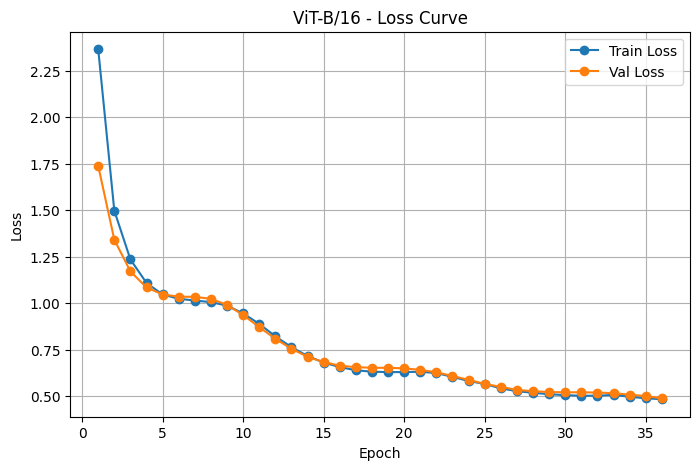

In [49]:
# ============================================================
# 16. Vẽ Loss Curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"],   marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT-B/16 - Loss Curve")
plt.legend()
plt.grid(True)
loss_curve_path = os.path.join(ASSETS_DIR, "vit_loss_curve.png")
plt.savefig(loss_curve_path, bbox_inches="tight")
print(f"Đã lưu: {loss_curve_path}")
plt.show()

Đã lưu: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\assets\vit_accuracy_curve.png


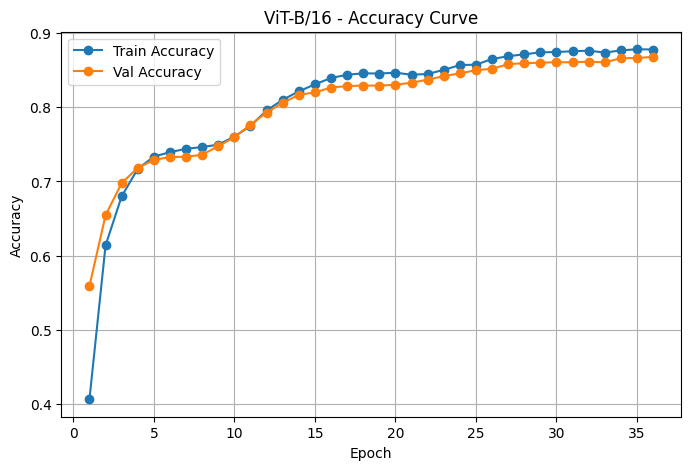

In [50]:
# ============================================================
# 17. Vẽ Accuracy Curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"],   marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT-B/16 - Accuracy Curve")
plt.legend()
plt.grid(True)
acc_curve_path = os.path.join(ASSETS_DIR, "vit_accuracy_curve.png")
plt.savefig(acc_curve_path, bbox_inches="tight")
print(f"Đã lưu: {acc_curve_path}")
plt.show()

In [51]:
# ============================================================
# 18. Load best checkpoint và đánh giá lại trên validation
# ============================================================

y_true_path = os.path.join(HISTORY_DIR, "vit_y_true.npy")
y_pred_path = os.path.join(HISTORY_DIR, "vit_y_pred.npy")

# Kiểm tra nếu đã lưu y_true và y_pred từ trước thì load thẳng lên (tiết kiệm thời gian)
if os.path.exists(y_true_path) and os.path.exists(y_pred_path):
    print("Tìm thấy kết quả dự đoán đã lưu. Đang load y_true và y_pred từ disk...")
    y_true = np.load(y_true_path)
    y_pred = np.load(y_pred_path)
    val_acc = accuracy_score(y_true, y_pred)
    print("Validation Accuracy (từ cache):", val_acc)
else:
    print("Không có cache dự đoán. Bắt đầu đánh giá toàn bộ tập validation...")
    if os.path.exists(VIT_BEST_PATH):
        best_checkpoint = torch.load(VIT_BEST_PATH, map_location=device)
        model_vit.load_state_dict(best_checkpoint["model_state_dict"])
        print("Đã load best checkpoint:", VIT_BEST_PATH)
        print("Best checkpoint epoch:", best_checkpoint.get("epoch"))
        print("Best checkpoint val acc:", best_checkpoint.get("best_val_acc"))
    else:
        print("Không tìm thấy best checkpoint, dùng model hiện tại.")

    val_loss, val_acc, y_true, y_pred = validate_one_epoch(
        model_vit, val_loader, criterion,
        device, use_amp=use_amp, epoch="best"
    )

    print("Validation Loss:", val_loss)
    print("Validation Accuracy:", val_acc)
    print("Accuracy check:", accuracy_score(y_true, y_pred))

    # Lưu lại để lần sau chạy không phải đợi
    np.save(y_true_path, y_true)
    np.save(y_pred_path, y_pred)
    print("Đã lưu kết quả dự đoán vào history để dùng lại sau.")

Tìm thấy kết quả dự đoán đã lưu. Đang load y_true và y_pred từ disk...
Validation Accuracy (từ cache): 0.8684009181331293


In [52]:
# ============================================================
# 19. Classification Report
# ============================================================

target_names = [
    str(class_mapping.get(str(i), f"Class {i}"))
    for i in range(NUM_CLASSES)
]

report_text = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report_text)

with open(REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Đã lưu classification_report:", REPORT_TXT_PATH)

              precision    recall  f1-score   support

       00000     0.9500    0.9048    0.9268        42
       00001     0.8458    0.8401    0.8429       444
       00002     0.7490    0.8289    0.7869       450
       00003     0.7509    0.7270    0.7387       282
       00004     0.7021    0.7500    0.7253       396
       00005     0.7183    0.6855    0.7015       372
       00006     0.9701    0.7738    0.8609        84
       00007     0.8830    0.8646    0.8737       288
       00008     0.6095    0.6809    0.6432       282
       00009     0.9924    0.8844    0.9353       294
       00010     0.7660    0.9204    0.8362       402
       00011     0.9019    0.9053    0.9036       264
       00012     0.9559    0.9810    0.9683       420
       00013     0.9839    0.9884    0.9861       432
       00014     1.0000    0.9808    0.9903       156
       00015     1.0000    0.9921    0.9960       126
       00016     1.0000    0.8452    0.9161        84
       00017     0.9952    

Đã lưu confusion matrix: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\assets\confusion_matrix_vit.png


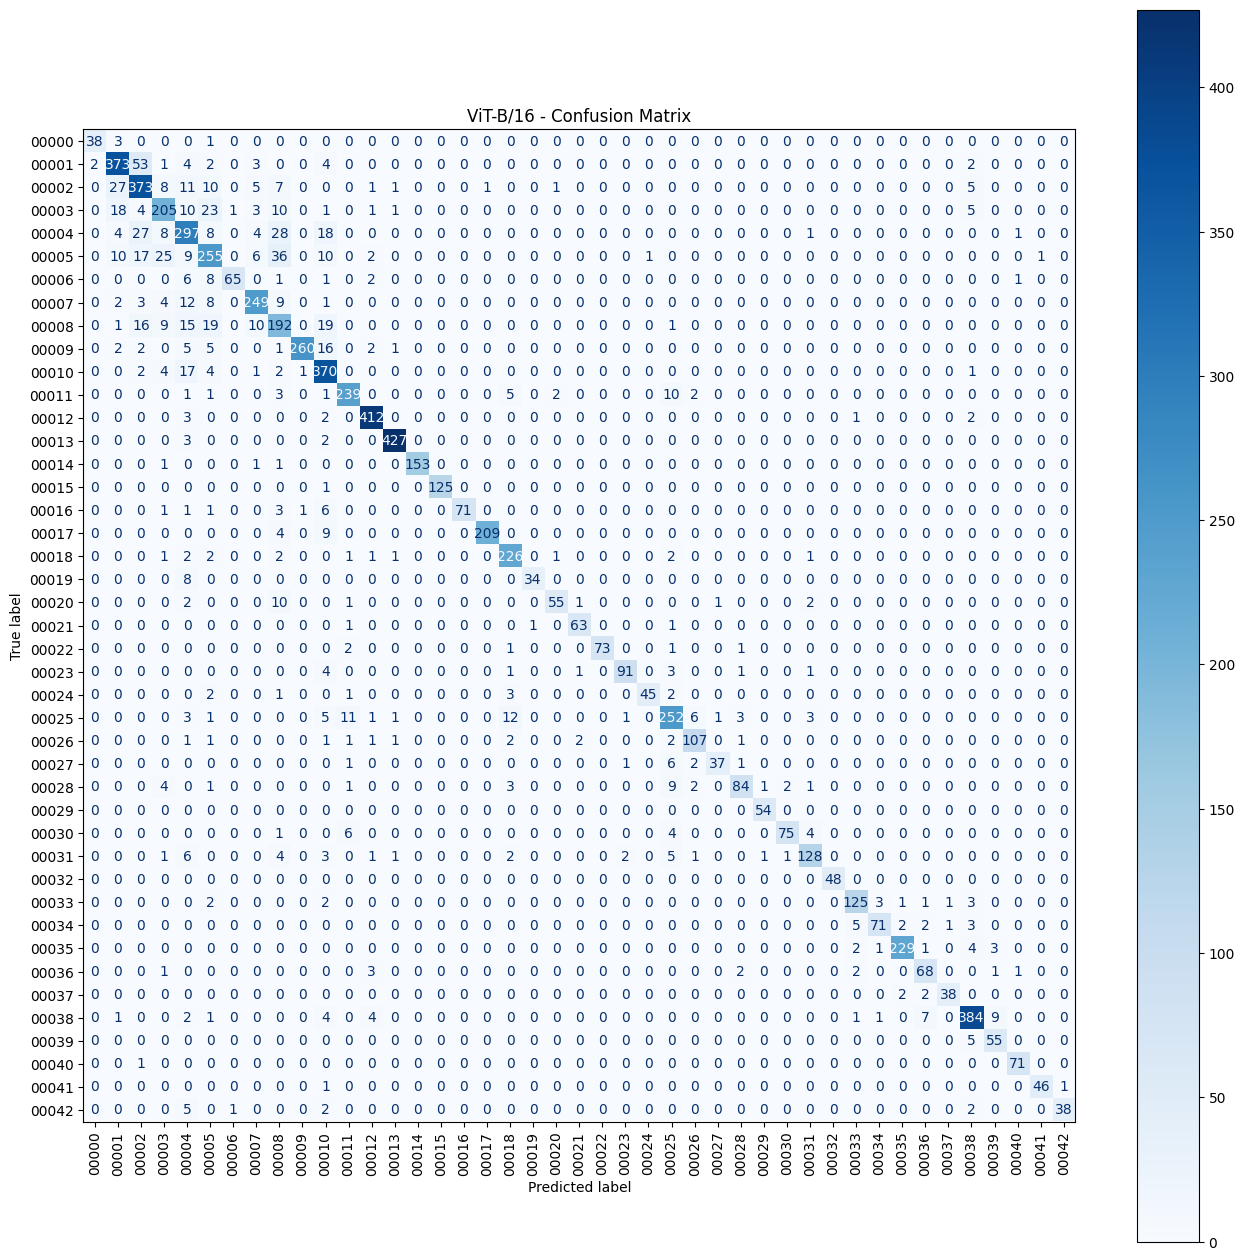

In [53]:
# ============================================================
# 19b. Vẽ và lưu Confusion Matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=target_names,
    cmap="Blues",
    xticks_rotation="vertical",
    ax=ax
)
plt.title("ViT-B/16 - Confusion Matrix")

cm_path = os.path.join(ASSETS_DIR, "confusion_matrix_vit.png")
plt.savefig(cm_path, bbox_inches="tight")
print(f"Đã lưu confusion matrix: {cm_path}")

plt.show()

In [54]:
# ============================================================
# Lưu cấu hình thí nghiệm ViT-B/16
# ============================================================

VIT_CONFIG_PATH = os.path.join(CONFIG_DIR, "vit_config.json")

vit_config = {
    "section":    "Section 3",
    "model_name": "ViT-B/16",
    "task":       "GTSRB Traffic Sign Classification",
    "num_classes": NUM_CLASSES,

    "base_dir":          BASE_DIR,
    "train_csv":         TRAIN_CSV,
    "val_csv":           VAL_CSV,
    "class_mapping_path": CLASS_MAPPING_PATH,

    "image_size":    IMG_SIZE,
    "batch_size":    BATCH_SIZE,
    "num_workers":   NUM_WORKERS,
    "epochs":        EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay":  WEIGHT_DECAY,
    "optimizer":     "AdamW",
    "scheduler":     "CosineAnnealingLR",
    "scheduler_params": {"T_max": EPOCHS, "eta_min": 1e-6},
    "loss_function": "CrossEntropyLoss",

    "pretrained_weights": "ViT_B_16_Weights.DEFAULT",
    "transfer_learning":  True,
    "freeze_backbone":    True,
    "trainable_layer":    "heads.head",

    "train_transform": {
        "Resize":        [IMG_SIZE, IMG_SIZE],
        "RandomRotation": 15,
        "ColorJitter":   {"brightness": 0.2, "contrast": 0.2},
        "Normalize":     {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]}
    },

    "val_transform": {
        "Resize":    [IMG_SIZE, IMG_SIZE],
        "Normalize": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]}
    },

    "checkpoint_paths": {
        "best":   VIT_BEST_PATH,
        "last":   VIT_LAST_PATH,
        "resume": VIT_RESUME_PATH
    },

    "history_paths": {
        "history_csv":           HISTORY_CSV_PATH,
        "history_json":          HISTORY_JSON_PATH,
        "classification_report": REPORT_TXT_PATH,
        "summary":               SUMMARY_JSON_PATH
    },

    "device": str(device),
    "seed":   SEED
}

with open(VIT_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(vit_config, f, ensure_ascii=False, indent=4)

print("Đã lưu ViT config tại:", VIT_CONFIG_PATH)

Đã lưu ViT config tại: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\configs\vit_config.json


In [64]:
import json
import os
import numpy as np

summary_vit = {
    "model": "ViT-B/16",
    "epochs": len(history_df),
    "best_epoch": int(history_df["val_acc"].idxmax() + 1),
    "best_val_acc": float(history_df["val_acc"].max()),
    "final_val_loss": float(history_df["val_loss"].iloc[-1]),
    "final_val_acc": float(history_df["val_acc"].iloc[-1]),
    "avg_epoch_time_sec": float(history_df["epoch_time_sec"].mean()),
    "history_csv_path": HISTORY_CSV_PATH,
    "classification_report_path": REPORT_TXT_PATH
}

summary_path = os.path.join(HISTORY_DIR, "summary_vit.json")

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_vit, f, ensure_ascii=False, indent=4)

print("Đã lưu:", summary_path)

Đã lưu: c:\Users\LENOVO\GTSRB-DeepLearning-Classification\history\summary_vit.json


In [65]:
import pandas as pd
import json
import os

history_path = os.path.join(HISTORY_DIR, "history_vit.csv")
summary_path = os.path.join(HISTORY_DIR, "summary_vit.json")

history = pd.read_csv(history_path)
print(history.to_string())

with open(summary_path, "r", encoding="utf-8") as f:
    summary = json.load(f)

print(json.dumps(summary, ensure_ascii=False, indent=4))

    epoch  train_loss  train_acc  val_loss   val_acc  epoch_time_sec
0       1    2.365781   0.406223  1.738562  0.558914      174.804592
1       2    1.497275   0.613734  1.341635  0.654425      178.955328
2       3    1.235210   0.679855  1.170833  0.697781      174.015688
3       4    1.108764   0.716996  1.084679  0.718312      173.810904
4       5    1.046786   0.733510  1.046739  0.728896      174.217000
5       6    1.023739   0.739471  1.035305  0.732976      194.945479
6       7    1.014322   0.744030  1.033899  0.733231      170.312935
7       8    1.005748   0.746358  1.023689  0.736037      173.158536
8       9    0.986869   0.749673  0.990702  0.747513      174.759383
9      10    0.945197   0.760449  0.936342  0.759628      174.669519
10     11    0.888549   0.774923  0.871399  0.776588      170.743877
11     12    0.821870   0.795741  0.808501  0.792910      174.008046
12     13    0.763814   0.810151  0.755180  0.806044      172.695265
13     14    0.715929   0.821500  